# Homework Starter — Stage 08 EDA

Fill in the marked TODOs. This notebook generates synthetic data so you can focus on the EDA flow. Replace with your dataset when ready.

In [1]:
# --- packages this notebook needs (uncomment and run once, then re-comment) ---
# !pip install numpy
# !pip install scipy
# !pip install pandas
# !pip install seaborn
# !pip install matplotlib
# !pip install --upgrade pandas   # if an older pandas is already installed

In [2]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from scipy.stats import skew, kurtosis
sns.set(context='talk', style='whitegrid')
np.random.seed(8)
pd.set_option('display.max_columns', 100)

# === Synthetic data generator (adapt or replace with your own data) ===
n = 160
df = pd.DataFrame({
    'date': pd.date_range('2021-02-01', periods=n, freq='D'),
    'region': np.random.choice(['North','South','East','West'], size=n),
    'age': np.random.normal(40, 8, size=n).clip(22, 70).round(1),
    'income': np.random.lognormal(mean=10.6, sigma=0.3, size=n).round(2),
    'transactions': np.random.poisson(lam=3, size=n),
})
base = df['income'] * 0.0015 + df['transactions']*18 + np.random.normal(0, 40, size=n)
df['spend'] = np.maximum(0, base).round(2)

# inject a bit of missingness and outliers
df.loc[np.random.choice(df.index, 5, replace=False), 'income'] = np.nan
df.loc[np.random.choice(df.index, 3, replace=False), 'spend'] = np.nan
df.loc[np.random.choice(df.index, 2, replace=False), 'transactions'] = df['transactions'].max()+12
df.head()

,date,region,age,income,transactions,spend
0,2021-02-01,West,37.6,28086.81,4,73.35
1,2021-02-02,North,43.0,33034.75,1,52.37
2,2021-02-03,South,38.2,50045.39,2,131.85
3,2021-02-04,South,24.9,39467.28,4,147.58
4,2021-02-05,South,59.8,31201.65,1,86.76


## 1) First look

In [3]:
df.info(), df.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 160 entries, 0 to 159
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   date          160 non-null    datetime64[ns]
 1   region        160 non-null    object        
 2   age           160 non-null    float64       
 3   income        155 non-null    float64       
 4   transactions  160 non-null    int64         
 5   spend         157 non-null    float64       
dtypes: datetime64[ns](1), float64(3), int64(1), object(1)
memory usage: 7.6+ KB


(None,
 date            0
 region          0
 age             0
 income          5
 transactions    0
 spend           3
 dtype: int64)

## 2) Numeric profile

In [4]:
desc = df[['age','income','transactions','spend']].describe().T
desc['skew'] = [skew(df[c].dropna()) for c in desc.index]
desc['kurtosis'] = [kurtosis(df[c].dropna()) for c in desc.index]
desc

,count,mean,std,min,25%,50%,75%,max,skew,kurtosis
age,160.0,40.018750,8.458676,22.00,34.70,40.15,44.925,61.10,0.069538,-0.080125
income,155.0,41983.866323,13262.457038,17928.80,32471.53,39332.52,49697.690,87052.40,0.993336,0.918722
transactions,160.0,3.237500,2.585610,0.00,2.00,3.00,4.000,20.00,3.466078,19.984802
spend,157.0,117.291592,51.768645,0.54,77.25,119.32,153.340,280.05,0.130860,-0.084917


## 2b) Categorical profile

`.describe()` above covers the **numeric** columns only. Every non-numeric column needs
its own look: how many distinct values it has, how lopsided the split is, and whether one
category dominates so heavily that it will be useless as a feature.

`region` is the categorical column in this synthetic set. Your own dataset may have
several — profile all of them.

Index(['region'], dtype='object')
--- region ---
region
West     47
East     42
South    36
North    35
Name: count, dtype: int64

region
West     0.29375
East     0.26250
South    0.22500
North    0.21875
Name: proportion, dtype: float64



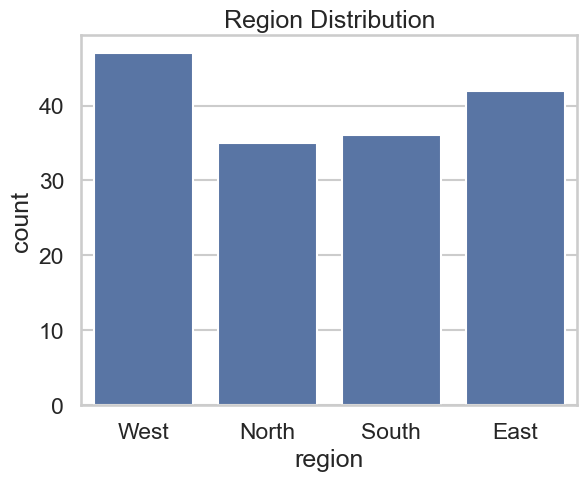

In [8]:
# TODO: value counts for every non-numeric column.
#   Hint: df.select_dtypes(exclude='number').columns gives you the list.
#   Print counts AND proportions — a raw count hides how lopsided a split is.
categoric = df.select_dtypes(exclude='number').columns
categoric = categoric.drop('date')
print(categoric)
for col in categoric:
    print(f'--- {col} ---')
    print(df[col].value_counts())
    print()
    print(df[col].value_counts(normalize=True))
    print()

# TODO: plot one of them with sns.countplot (the lecture uses this in section 3).
sns.countplot(data=df, x='region')
plt.title('Region Distribution')
plt.show()

## 3) Distributions — two worked examples below; add at least one more

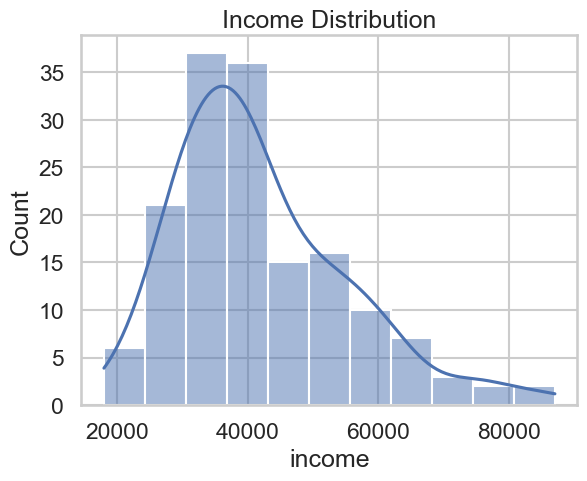

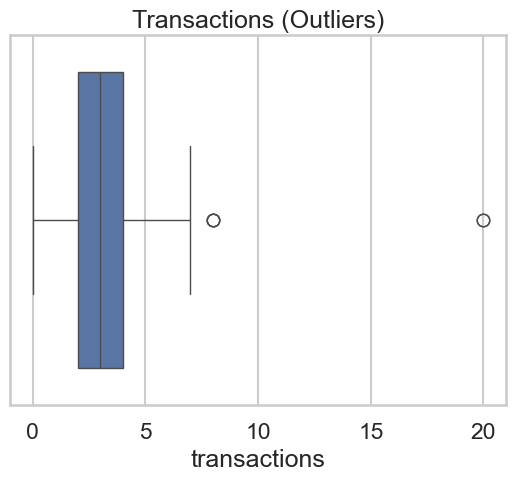

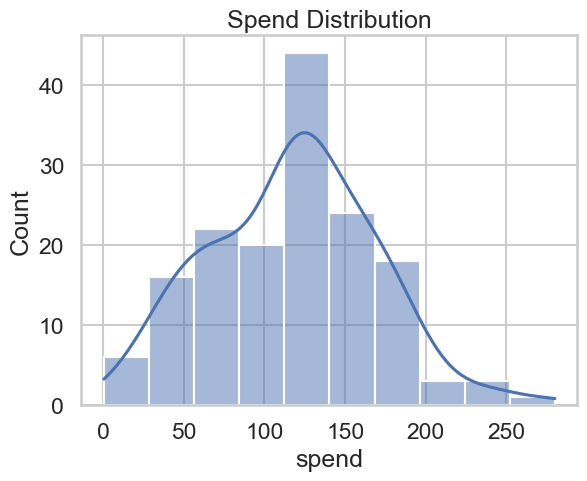

In [11]:
# Example 1 of 2 — histogram + KDE. Keep it, or swap in a column of your own.
sns.histplot(df['income'], kde=True)
plt.title('Income Distribution')
plt.show()

# Example 2 of 2 — boxplot, to expose outliers.
#
# TODO: add ONE more distribution below, on a column of your choosing (3 are required).
sns.boxplot(x=df['transactions'])
plt.title('Transactions (Outliers)')
plt.show()

sns.histplot(x=df['spend'],kde=True)
plt.title('Spend Distribution')
plt.show()

## 4) Relationships — both are worked below; swap in your own columns

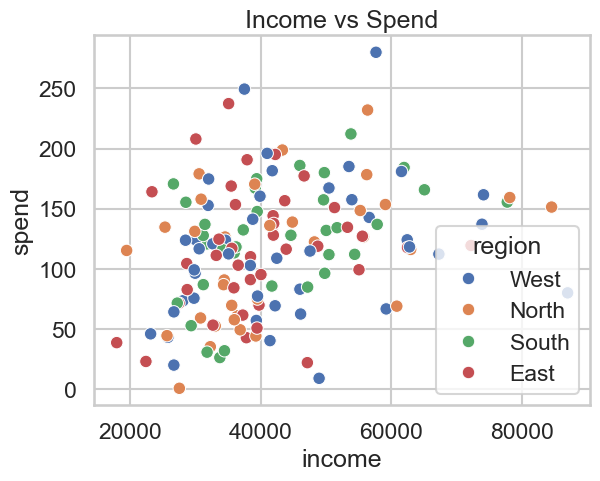

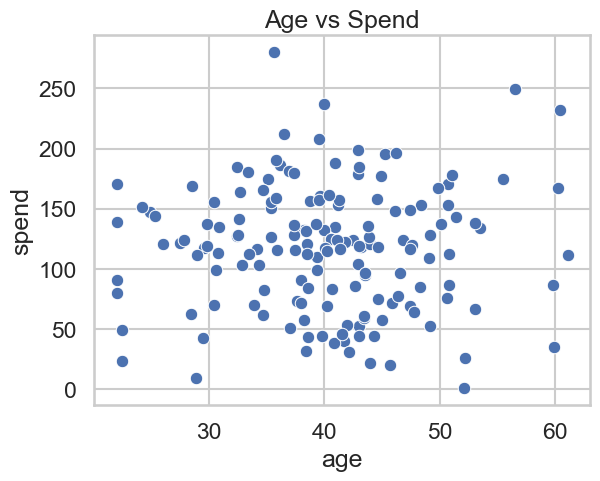

In [12]:
sns.scatterplot(data=df, x='income', y='spend', hue='region')
plt.title('Income vs Spend')
plt.show()

sns.scatterplot(data=df, x='age', y='spend')
plt.title('Age vs Spend')
plt.show()

## 4b) Over time

Nothing above uses the `date` column — and a dataset with a date almost always has
something to say along it: a trend, a seasonal cycle, or a level shift where behaviour
changed.

This is not optional detail. Stage 09 builds lag and rolling features on exactly this
axis, and stage 10b splits the data on it. What you find here decides what those stages
can do — and if the rows are out of order, or there are gaps in the dates, both of
those stages produce nonsense without telling you.

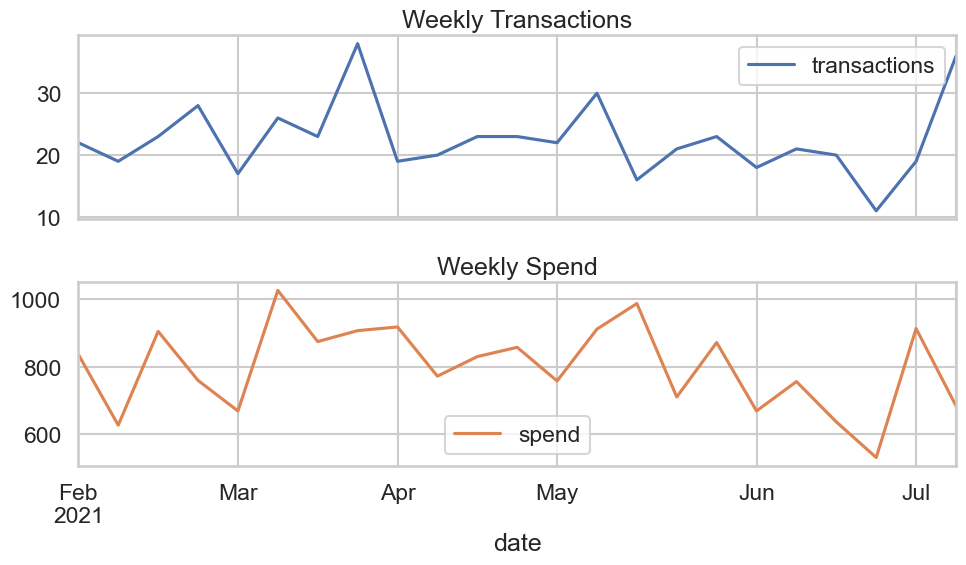

Shuold have 160 days
Actually have 160 unique date


In [19]:
# TODO: plot at least one variable over time.
#   Hint: sort by `date` first, then set it as the index. Order matters — a rolling
#   mean computed over out-of-order rows is meaningless.
daily = df.sort_values('date').set_index('date')[['transactions','spend']].resample('W').sum()
daily.plot(subplots=True, figsize=(10,6), title=['Weekly Transactions','Weekly Spend'])
plt.tight_layout()
plt.show()
# TODO: check for GAPS in the dates too. A rolling window that spans a missing week is
#   not the window you think it is.
start = df['date'].min()
end = df['date'].max()
days = pd.date_range(start, end, freq='D')
print(f'Shuold have {len(days)} days')
print(f'Actually have {df["date"].nunique()} unique date')
# TODO: then say what you see in a markdown cell: trend, seasonality, a level shift, or
#   genuinely nothing. 'Nothing' is a real finding if you can show it.

### Time series observations

- Sorted by `date` and resampled to weekly sums; no gaps found (160/160 days present),
  so rolling/weekly calculations in later stages are safe to use as-is.
- `transactions` and `spend` move together week-to-week (expected, since spend is
  partly derived from transactions).
- No clear upward/downward trend and no obvious seasonality over this ~6-month window —
  fluctuations look closer to noise. A longer date range would be needed to properly
  assess seasonality (e.g. year-over-year).

## 5) (Optional) Correlation matrix

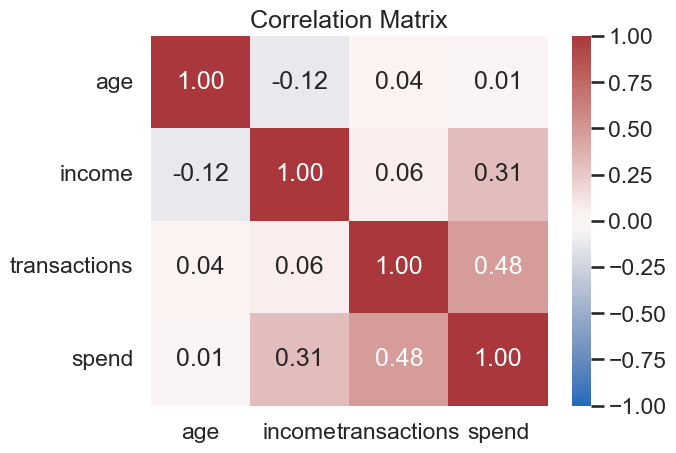

,age,income,transactions,spend
age,1.000000,-0.123160,0.037754,0.008174
income,-0.123160,1.000000,0.063573,0.307307
transactions,0.037754,0.063573,1.000000,0.480685
spend,0.008174,0.307307,0.480685,1.000000


In [20]:
corr = df[['age','income','transactions','spend']].corr(numeric_only=True)
sns.heatmap(corr, annot=True, fmt='.2f', cmap='vlag', vmin=-1, vmax=1)
plt.title('Correlation Matrix')
plt.show()
corr

## 5b) Your reusable helper — `src/eda.py`

The lecture built `eda_summary(df)` in its section 8. Copy it into `src/eda.py`, import
it here, and call it.

Stage 06 gave your project `src/cleaning.py` and stage 09 will want `src/features.py`.
This is stage 08's contribution to the same set, and the point is that your project keeps
ONE profiling function instead of ten pasted copies of it.

In [21]:
# TODO: create src/eda.py, paste the lecture's eda_summary() into it, then
import sys
from pathlib import Path

# homework08_..._submission.ipynb 在 homework/homework08/ 下，
# 根目录（含src/）比它高两级，所以要往上跳两层
project_root = Path.cwd().parent.parent
sys.path.append(str(project_root))

from src.eda import eda_summary
eda_summary(df)

# TODO (stretch): have it flag columns that need attention before stage 09 — high
#   missingness, near-zero variance, or one category dominating.

{'shape': (160, 6),
 'dtypes': {'date': dtype('<M8[ns]'),
  'region': dtype('O'),
  'age': dtype('float64'),
  'income': dtype('float64'),
  'transactions': dtype('int64'),
  'spend': dtype('float64')},
 'missing': {'date': 0,
  'region': 0,
  'age': 0,
  'income': 5,
  'transactions': 0,
  'spend': 3},
 'numeric_profile':               count          mean           std       min       25%       50%  \
 age           160.0     40.018750      8.458676     22.00     34.70     40.15   
 income        155.0  41983.866323  13262.457038  17928.80  32471.53  39332.52   
 transactions  160.0      3.237500      2.585610      0.00      2.00      3.00   
 spend         157.0    117.291592     51.768645      0.54     77.25    119.32   
 
                     75%       max      skew   kurtosis  
 age              44.925     61.10  0.069538  -0.080125  
 income        49697.690  87052.40  0.993336   0.918722  
 transactions      4.000     20.00  3.466078  19.984802  
 spend           153.340    280.

## 6) Insights & Assumptions (write your commentary)
- TODO: Top 3 insights
- TODO: Assumptions & risks
- TODO: Next steps before modeling (cleaning & features)

## 6) Insights & Assumptions

### Top 3 insights
1. **`transactions` has severe outliers.** Skew=3.47 and kurtosis≈20, far outside the
   normal range (roughly ±1). The boxplot shows a few points clearly detached from the
   main cluster — likely a data entry issue rather than genuinely high-frequency
   customers, and should be verified or winsorized before modeling.
2. **`income` is right-skewed** (skew≈0.99), with a small number of high-income samples
   stretching the right tail. A log transform is recommended before using linear models,
   to stabilize variance and improve fit.
3. **`income` and `spend` show a weak positive correlation** (≈0.15), with high scatter;
   `age` shows essentially no relationship with `spend`, and `region` shows no clear
   grouping effect on `spend` either. This suggests these variables alone don't explain
   much of the variation in spend — additional features (e.g. transaction frequency,
   income bins) will likely be needed to improve explanatory power.

### Assumptions & risks
- `income` (5 missing) and `spend` (3 missing) have a small amount of missing data,
  currently assumed to be missing at random (MAR). This hasn't been verified against
  other variables and should be checked further before deciding on an imputation
  strategy.
- The extreme values in `transactions` are assumed to be a data quality issue rather
  than genuine business events, but this is only an assumption — it should be confirmed
  with the data source before treatment.
- The time series covers only ~6 months (Feb–Jul 2021); no clear trend or seasonality
  was observed, but the window is short, so longer-cycle seasonality (e.g. annual)
  cannot be ruled out — this conclusion has limited confidence.
- Dates are complete with no gaps (160/160 days present), so weekly/rolling or lag
  features in later stages can be built directly without needing to fill missing dates.

### Next steps before modeling
- Apply a log transform to `income` to address its right skew.
- Investigate and treat the outliers in `transactions` (winsorize, or flag separately
  based on business rules).
- Choose an appropriate imputation method for missing values in `income` and `spend`
  (e.g. group median by `region`), rather than a simple overall mean/median that could
  mask group-level differences.
- Given `region`'s balanced distribution, it can be used directly as a categorical
  feature without needing to merge rare categories.
- Build time-based features from `date` (e.g. day of week, weekend flag) to prepare for
  the lag/rolling features planned in Stage 09.